In [1]:
!pip install mlflow dagshub --quiet

import os
import time
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils import resample
from scipy.stats import wilcoxon, ttest_rel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from pathlib import Path
from google.colab import userdata
from PIL import Image
import dagshub
import mlflow
import mlflow.pytorch
import mlflow.data

In [2]:
DAGSHUB_USERNAME = userdata.get("DAGSHUB_USERNAME")
DAGSHUB_TOKEN    = userdata.get("DAGSHUB_TOKEN")
DAGSHUB_REPO     = "mlflow_demo_repo"
os.environ["DAGSHUB_USER_TOKEN"] = DAGSHUB_TOKEN

dagshub.init(repo_name=DAGSHUB_REPO, repo_owner=DAGSHUB_USERNAME, mlflow=True)
mlflow.set_experiment("crop_recommendation")

Accessing as DmitriyShalashov

Initialized MLflow to track repo "DmitriyShalashov/mlflow_demo_repo"

Repository DmitriyShalashov/mlflow_demo_repo initialized!

<Experiment: artifact_location='mlflow-artifacts:/e10154dc71ec40b29aa5c6f20465afcb', creation_time=1781558740790, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1781558740790, lifecycle_stage='active', name='crop_recommendation', tags={}, trace_location=None, workspace='default'>

In [3]:
sns.set_theme(style="whitegrid")

root = Path(kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset"))
crops = pd.read_csv(root / "Crop_recommendation.csv")
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
crops.head()

print("размер:", crops.shape)
print("пропуски:", crops.isna().sum().sum())
print("дубли строк:", crops.duplicated().sum())
crops.dtypes

Using Colab cache for faster access to the 'crop-recommendation-dataset' dataset.
размер: (2200, 8)
пропуски: 0
дубли строк: 0


,0
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object


In [4]:
crops[features].describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


Text(0.5, 1.0, 'Баланс классов: 22 культур')

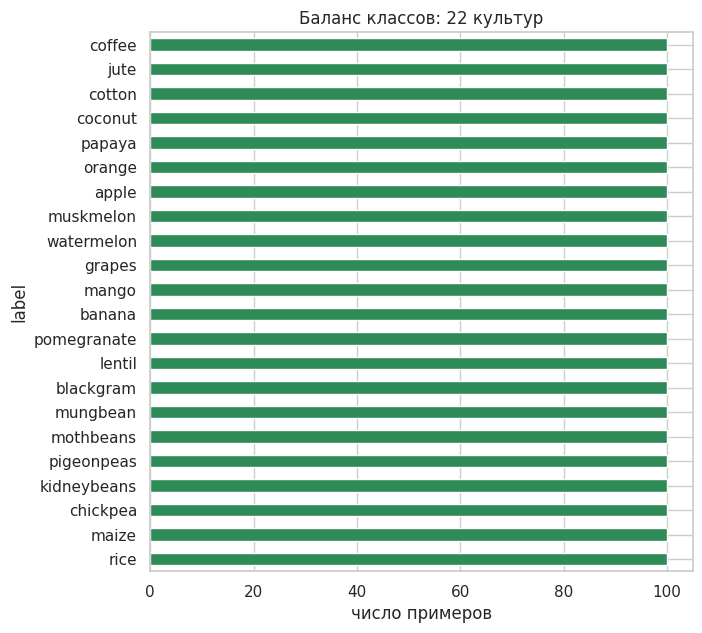

In [5]:
counts = crops["label"].value_counts()
ax = counts.sort_values().plot.barh(figsize=(7, 7), color="seagreen")
ax.set_xlabel("число примеров")
ax.set_title(f"Баланс классов: {len(counts)} культур")

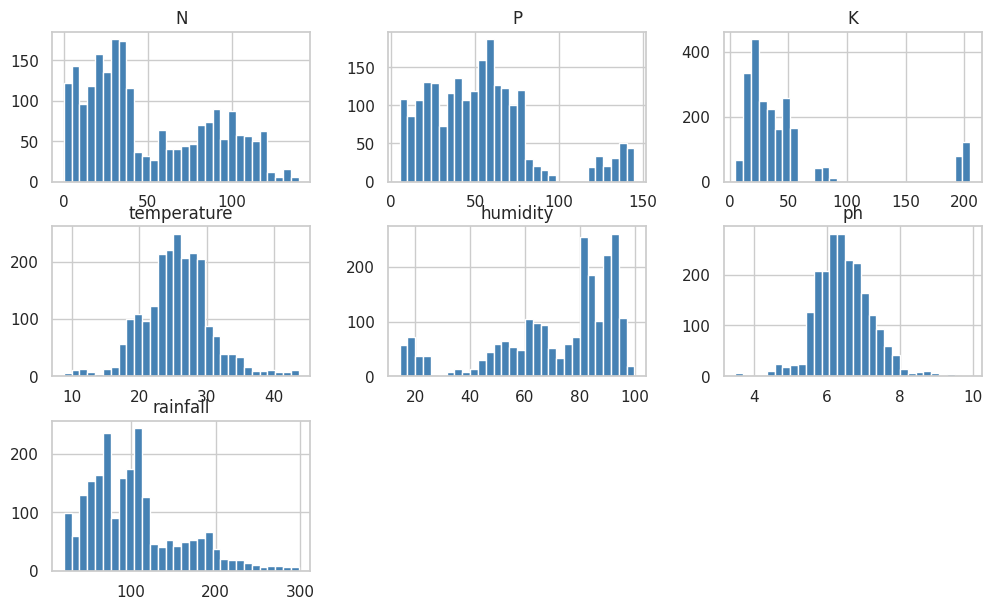

In [6]:
crops[features].hist(bins=30, figsize=(12, 7), color="steelblue", edgecolor="white");

Text(0.5, 1.0, 'Корреляции признаков')

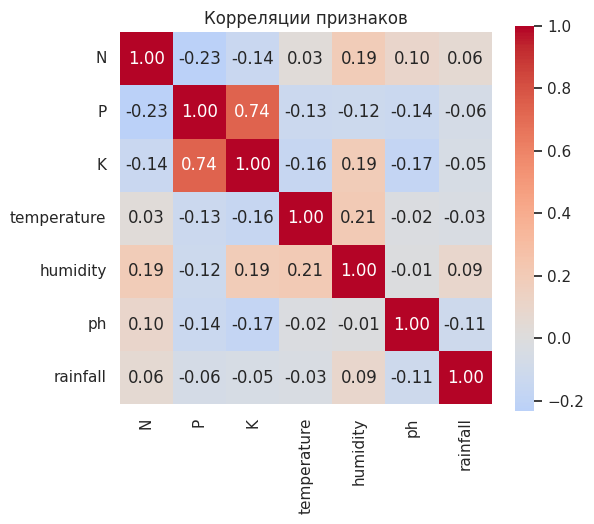

In [7]:
plt.figure(figsize=(6, 5))
sns.heatmap(crops[features].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Корреляции признаков")

Text(0.5, 1.0, 'Средний агрофон по культурам')

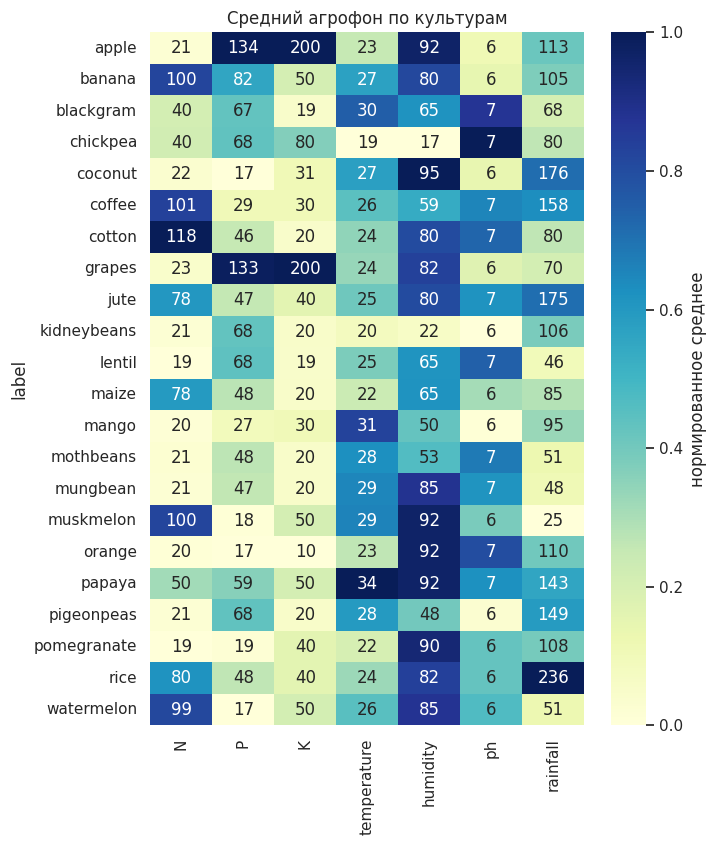

In [8]:
profile = crops.groupby("label")[features].mean()
normed = (profile - profile.min()) / (profile.max() - profile.min())
plt.figure(figsize=(7, 9))
sns.heatmap(normed, annot=profile.round(0), fmt=".0f", cmap="YlGnBu",
            cbar_kws={"label": "нормированное среднее"})
plt.title("Средний агрофон по культурам")

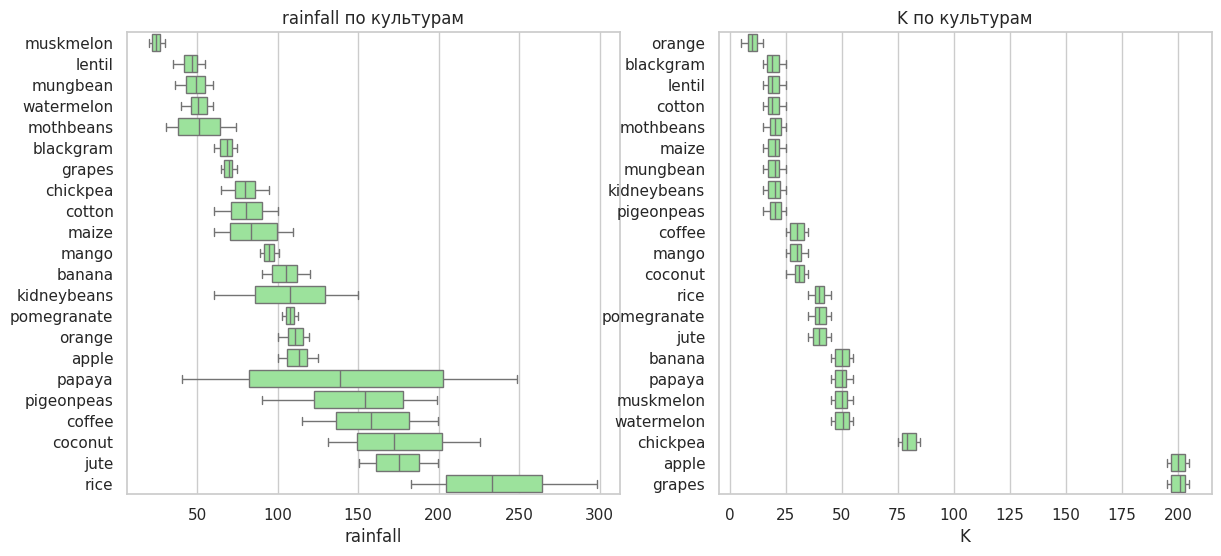

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, feat in zip(axes, ["rainfall", "K"]):
    order = crops.groupby("label")[feat].median().sort_values().index
    sns.boxplot(data=crops, x=feat, y="label", order=order, ax=ax, color="lightgreen")
    ax.set_title(f"{feat} по культурам")
    ax.set_ylabel("")

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

X = crops.drop('label', axis=1).values
y = crops['label'].values

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#логируем получившиеся датасеты
train_df = pd.DataFrame(X_train, columns=features)
train_df['label'] = y_train
train_df.to_csv("crop_train_data.csv", index=False)
mlflow.log_artifact("crop_train_data.csv", artifact_path="datasets/raw")


val_df = pd.DataFrame(X_val, columns=features)
val_df['label'] = y_val
val_df.to_csv("crop_val_data.csv", index=False)
mlflow.log_artifact("crop_val_data.csv", artifact_path="datasets/raw")

test_df = pd.DataFrame(X_test, columns=features)
test_df['label'] = y_test
test_df.to_csv("crop_test_data.csv", index=False)
mlflow.log_artifact("crop_test_data.csv", artifact_path="datasets/raw")

mlflow.log_params({
    "test_size": 0.30,
    "val_size": 0.15,
    "random_state": 42,
    "stratify": True
})

#Перекладывани на тензоры для работы с gpu
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.LongTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.LongTensor(y_test).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

input_dim = X_train.shape[1]
num_classes = len(np.unique(y))

print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test:  {X_test.shape}\n")

cuda
Train: (1540, 7)
Val: (330, 7)
Test:  (330, 7)



In [11]:
import joblib

mlflow.end_run()

with mlflow.start_run(run_name="crop_preprocessing_objects"):
  joblib.dump(scaler, "crop_scaler.pkl")
  mlflow.log_artifact("crop_scaler.pkl", artifact_path="preprocessing")

  joblib.dump(le, "crop_label_encoder.pkl")
  mlflow.log_artifact("crop_label_encoder.pkl", artifact_path="preprocessing")

🏃 View run trusting-cod-115 at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/0/runs/26339a928aa14cbba0490fe3c05a1285
🧪 View experiment at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/0
🏃 View run crop_preprocessing_objects at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/0/runs/8823be3145bb4ba6bb284ef957a316ca
🧪 View experiment at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/0


In [12]:
class NN0(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 4),
            nn.ReLU(),
            nn.Linear(4, num_classes)
        )
    def forward(self, x): return self.net(x)

class NN1(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x): return self.net(x)

class NN2(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x): return self.net(x)

#Skip connection блок
class SC(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()
    def forward(self, x): return self.relu(x + self.block(x))

class NN3(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, 64)
        self.res_block1 = SC(64)
        self.res_block2 = SC(64)
        self.output_layer = nn.Linear(64, num_classes)
    def forward(self, x):
        x = torch.relu(self.input_layer(x))
        x = self.res_block1(x)
        x = self.res_block2(x)
        return self.output_layer(x)

In [13]:
models_d = {
    "NN0": NN0(input_dim, num_classes).to(device),
    "NN1": NN1(input_dim, num_classes).to(device),
    "NN2": NN2(input_dim, num_classes).to(device),
    "ResNet": NN3(input_dim, num_classes).to(device)
}

results = []

for name, model in models_d.items():
    with mlflow.start_run(run_name=f"crop_{name}"):
        mlflow.log_params({
            "model_name": name,
            "input_dim": input_dim,
            "num_classes": num_classes,
            "epochs": 30,
            "learning_rate": 0.005,
            "optimizer": "AdamW",
            "weight_decay": 1e-4,
            "batch_size": 32
        })

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.AdamW(model.parameters(), lr=0.005)

        for epoch in range(30):
            model.train()
            epoch_loss = 0.0
            for batch_x, batch_y in train_loader:
              optimizer.zero_grad()
              outputs = model(batch_x)
              loss = criterion(outputs, batch_y)
              loss.backward()
              optimizer.step()

              epoch_loss += loss.item() * len(batch_x)

            train_loss = epoch_loss / len(train_dataset)

            model.eval()
            with torch.no_grad():
              val_logits = model(X_val_t)
              val_preds = torch.argmax(val_logits, dim=1).cpu().numpy()
              val_acc = accuracy_score(y_val_t.cpu().numpy(), val_preds)

              mlflow.log_metrics({
                    "train_loss": train_loss,
                    "val_accuracy": val_acc
              }, step=epoch)

        model.eval()
        with torch.no_grad():
          test_logits = model(X_test_t)
          test_preds = torch.argmax(test_logits, dim=1).cpu().numpy()

        y_test_true = y_test_t.cpu().numpy()
        test_acc = accuracy_score(y_test_true, test_preds)
        test_f1 = f1_score(y_test_true, test_preds, average='weighted')

        mlflow.log_metrics({
            "test_accuracy": test_acc,
            "test_f1": test_f1
        })

        signature = mlflow.models.infer_signature(
            X_train[:5],
            model(torch.tensor(X_train[:5], dtype=torch.float32).to(device)).detach().cpu().numpy()
        )
        mlflow.pytorch.log_model(model, artifact_path="model", signature=signature)

        results.append({
            "Архитектура": name,
            "Test Acc": round(test_acc, 4),
            "Test F1": round(test_f1, 4)
        })


print(pd.DataFrame(results).to_string(index=False))

2026/06/16 04:44:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 04:44:28 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/16 04:44:28 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/16 04:44:35 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label

🏃 View run crop_NN0 at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/0/runs/dc2a8e554e5e45efb57cd884fd4abda1
🧪 View experiment at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/0


2026/06/16 04:46:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 04:46:20 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/16 04:46:20 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/16 04:46:25 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label

🏃 View run crop_NN1 at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/0/runs/22b56f2c2aa14027b2a606fcd30377fa
🧪 View experiment at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/0


2026/06/16 04:47:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 04:47:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/16 04:47:44 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/16 04:47:49 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label

🏃 View run crop_NN2 at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/0/runs/cbf8eb847f604ce681deb85c8fb775a1
🧪 View experiment at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/0


2026/06/16 04:49:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 04:49:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/16 04:49:21 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/16 04:49:26 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label

🏃 View run crop_ResNet at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/0/runs/06f93c5003794686b7cdfc0049717ef3
🧪 View experiment at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/0
Архитектура  Test Acc  Test F1
        NN0    0.9091   0.9075
        NN1    0.9818   0.9818
        NN2    0.9879   0.9878
     ResNet    0.9818   0.9816


In [15]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from sklearn.utils import resample

with mlflow.start_run(run_name="crop_statistical_tests"):

    y_true = y_test_t.cpu().numpy()

    def get_preds(model):
        model.eval()
        with torch.no_grad():
            outputs = model(X_test_t)
            return torch.argmax(outputs, dim=1).cpu().numpy()

    preds0 = get_preds(models_d["NN0"])
    preds1 = get_preds(models_d["NN1"])
    preds2 = get_preds(models_d["NN2"])
    preds_res = get_preds(models_d["ResNet"])

    def generate_bootstrap_scores(y_true, y_pred,n=100):
      scores = []
      for i in range(n):
        ix = resample(np.arange(len(y_true)), random_state=i)
        scores.append(accuracy_score(y_true[ix], y_pred[ix]))
      return scores

    scores0 = generate_bootstrap_scores(y_true, preds0)
    scores1 = generate_bootstrap_scores(y_true, preds1)
    scores2 = generate_bootstrap_scores(y_true, preds2)
    scores_res = generate_bootstrap_scores(y_true, preds_res)

    img_pairs = [("NN0",scores0), ("NN1", scores1), ("NN2", scores2),
      ("ResNet",scores_res)
                 ]
    names = []
    p_values = []

    for i, (n1, s1) in enumerate(img_pairs):
      for j, (n2, s2) in enumerate(img_pairs):
        if i >= j:
          continue

        stat, p_val = wilcoxon(s1, s2)
        names.append((n1, n2))
        p_values.append(p_val)

    rej, p_corr, _, _ = multipletests(p_values, alpha=0.05, method='holm')

    for (n1, n2), p_raw, p_corr, rej in zip(names, p_values, p_corr, rej):
      mlflow.log_metrics({
        f"{n1}_{n2}_p_value": np.round(p_corr, 5),
        f"{n1}_{n2}_significant": 1 if rej else 0,
    })
      print(f"{n1}_{n2}_p_value ", p_corr)

NN0_NN1_p_value  2.2638945535073673e-17
NN0_NN2_p_value  2.2638945535073673e-17
NN0_ResNet_p_value  2.2638945535073673e-17
NN1_NN2_p_value  1.5555004580922181e-12
NN1_ResNet_p_value  0.8968574744347041
NN2_ResNet_p_value  3.870416359452904e-09
🏃 View run crop_statistical_tests at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/0/runs/3478461067c74af2adbbcf200539025d
🧪 View experiment at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/0


В датасете по 100 примеров на класс, при этом данные довольно синтетические, различия в предсказаниях между архитектурами статистически незначимы

In [16]:
mlflow.set_experiment("plant_disease_classification")

path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

train_dir = os.path.join(path, "New Plant Diseases Dataset(Augmented)", "New Plant Diseases Dataset(Augmented)", "train")
val_dir = os.path.join(path, "New Plant Diseases Dataset(Augmented)", "New Plant Diseases Dataset(Augmented)", "valid")

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.


In [17]:
def class_counts(directory):
    return pd.Series({
        d.name: sum(1 for _ in d.iterdir())
        for d in sorted(Path(directory).iterdir()) if d.is_dir()
    })

train_counts = class_counts(train_dir)
valid_counts = class_counts(val_dir)
print(f"{len(train_counts)} классов | train {train_counts.sum()} | valid {valid_counts.sum()}")

38 классов | train 70295 | valid 17572


Text(0.5, 1.0, 'Размер классов')

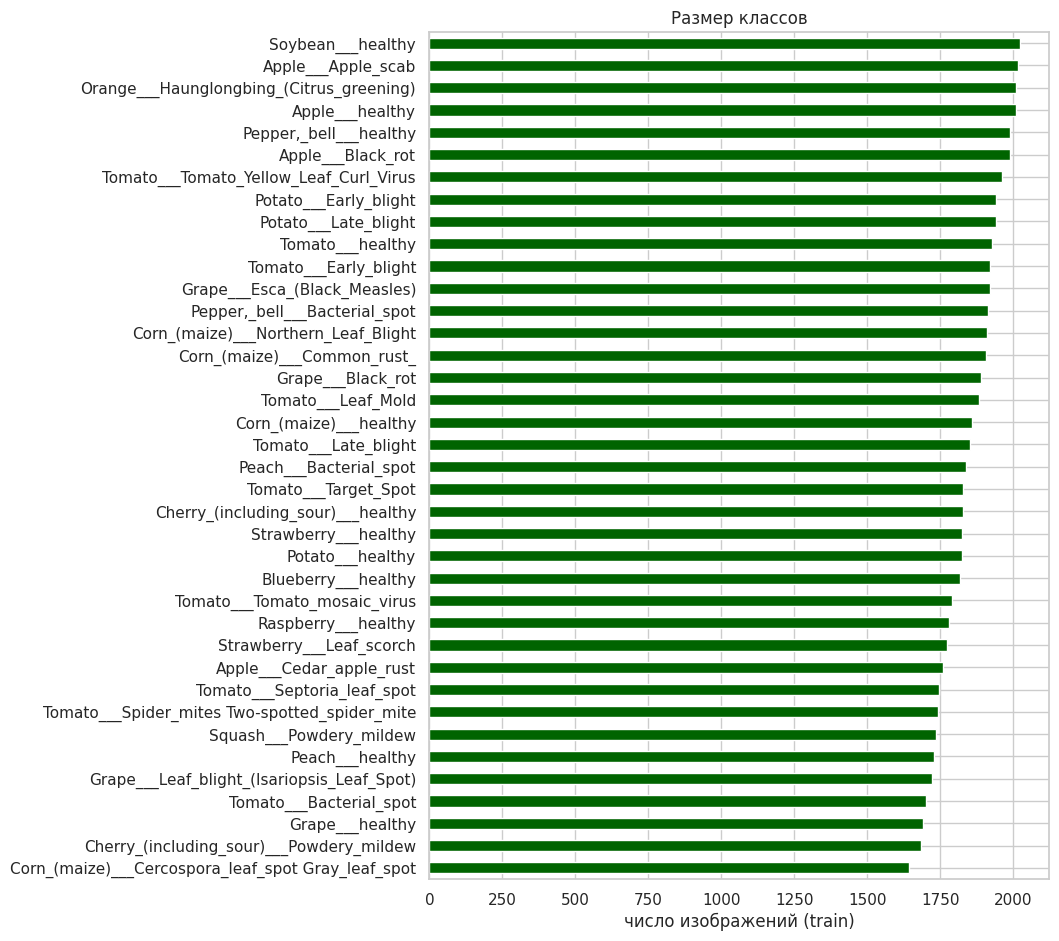

In [18]:
ax = train_counts.sort_values().plot.barh(figsize=(8, 11), color="darkgreen")
ax.set_xlabel("число изображений (train)")
ax.set_title("Размер классов")

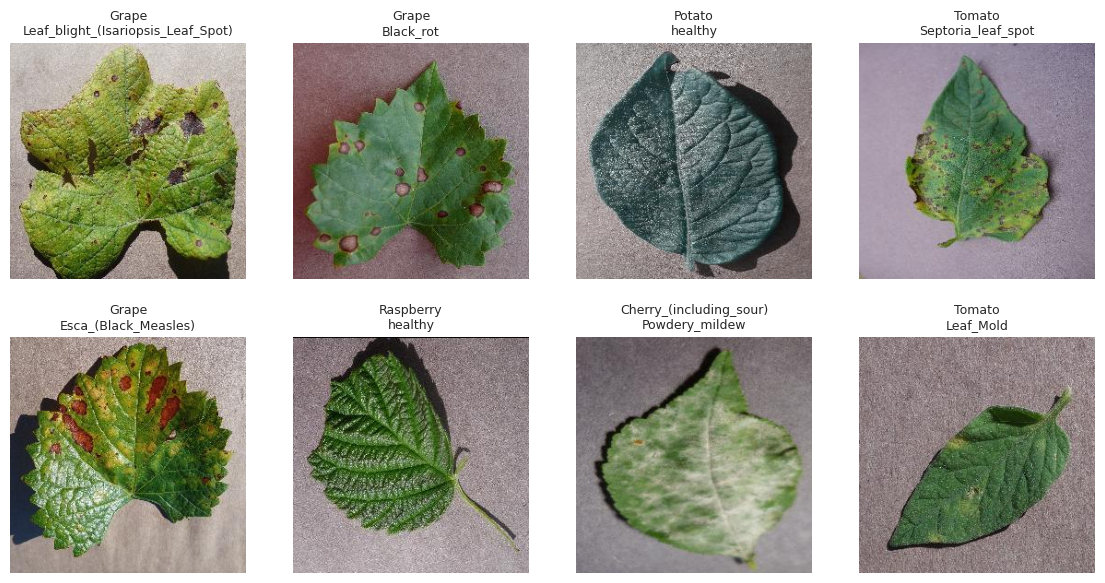

In [19]:
sample_classes = random.sample(sorted(train_counts.index), 8)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, cls in zip(axes.ravel(), sample_classes):
    img_path = next((Path(train_dir) / cls).iterdir())
    ax.imshow(Image.open(img_path))
    ax.set_title(cls.replace("___", "\n"), fontsize=9)
    ax.axis("off")

In [20]:
IMG_SIZE = 128
BATCH_SIZE = 64

#https://stackoverflow.com/questions/65467621/what-are-the-numbers-in-torch-transforms-normalize-and-how-to-select-them
#отсюда берем значения нормализации
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=val_dir, transform=eval_transforms)

#разбиваем тестовый датасет на валидационную выборку и тестовую, через индексы
valid_indices, test_indices = train_test_split(
    range(len(val_dataset)),
    test_size=0.5,
    random_state=42,
    stratify=val_dataset.targets
)

val_sub = Subset(val_dataset, valid_indices)
test_sub = Subset(val_dataset, test_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_sub, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_sub, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(train_dataset.classes)
print(f"Classes: {num_classes}")
print(f"Train: {len(train_dataset)}")
print(f"Valid: {len(test_sub)}")
print(f"Test:  {len(test_sub)}\n")

Classes: 38
Train: 70295
Valid: 8786
Test:  8786



In [21]:
with mlflow.start_run(run_name="plant_disease_classification_data"):

  mlflow.log_params({
          "plant_dataset_source": "https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset",
          "plant_train_samples": len(train_dataset),
          "plant_val_samples": len(val_sub),
          "plant_test_samples": len(test_sub),
          "plant_split_random_state": 42,
          "plant_train_val_test_sizes": "70/15/15",
      })
  mlflow.log_params({
          "img_size": IMG_SIZE,
          "batch_size": BATCH_SIZE,
          "normalize_mean": [0.485, 0.456, 0.406],
          "normalize_std": [0.229, 0.224, 0.225],
          "augmentation_flip": True,
          "augmentation_rotation": 15
      })

🏃 View run plant_disease_classification_data at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/1/runs/20bde0b1c18444d2aae43aba7cfa2ad0
🧪 View experiment at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/1


In [22]:
class CNN0(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.cls = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.mlp(x)
        x = x.view(x.size(0), -1)
        x = self.cls(x)
        return x

def get_resnet_frozen():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    for param in model.parameters():
      param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(512, num_classes)
    )
    for param in model.fc.parameters():
      param.requires_grad = True

    return model.to(device)

#https://www.geeksforgeeks.org/deep-learning/residual-networks-resnet-deep-learning/
def get_resnet():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

#https://docs.pytorch.org/vision/main/models/generated/torchvision.models.mobilenet_v3_small.html
def get_mobilenet():
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 1024),
        nn.Hardswish(),
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(1024, num_classes)
    )
    return model.to(device)

#https://www.geeksforgeeks.org/computer-vision/efficientnet-architecture/
def get_efficientnet():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    return model.to(device)

def get_cnn0():
    model = CNN0(num_classes)
    model = model.to(device)
    return model

In [23]:
models_d = [
    (get_cnn0, "CNN0"),
    (get_resnet, "ResNet-18"),
    (get_resnet_frozen, "ResNet-18 frozen"),
    (get_mobilenet, "MobileNet-V3-Small"),
    (get_efficientnet, "EfficientNet-B0")
]

cv_results = []

for model_fn, name in models_d:
    with mlflow.start_run(run_name=f"plant_disease_{name.replace('-', '_')}"):
        mlflow.log_params({
          "model_name": name,
          "epochs": 2,
          "learning_rate": 0.001,
          "optimizer": "AdamW",
          "weight_decay": 1e-4,
          "batch_size": BATCH_SIZE,
          "img_size": IMG_SIZE,
          "num_classes": num_classes
        })
        img_ds_desc = pd.DataFrame({
          "train_samples": [len(train_dataset)],
          "val_samples": [len(val_sub)],
          "test_samples": [len(test_sub)],
          "num_classes": [num_classes],
          "image_size": [IMG_SIZE]
        })
        img_ds = mlflow.data.from_pandas(img_ds_desc, source="plant_disease_dataset", name="plant_disease_dataset")

        mlflow.log_input(img_ds, context="training")

        model = model_fn()
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.AdamW(model.parameters(), lr=0.001)

        st_time = time.time()

        for epoch in range(2):
          model.train()
          epoch_loss = 0.0

          for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * len(inputs)

          train_loss = epoch_loss / len(train_dataset)

          model.eval()
          val_preds = []
          val_labels = []

          with torch.no_grad():
            for inputs, labels in val_loader:
              inputs = inputs.to(device)
              outputs = model(inputs)

              preds = torch.argmax(outputs, dim=1).cpu().numpy()
              val_preds.extend(preds)
              val_labels.extend(labels.numpy())

          val_acc = accuracy_score(val_labels, val_preds)
          val_f1 = f1_score(val_labels, val_preds, average='weighted')

          mlflow.log_metrics({
                "train_loss": train_loss,
                "val_accuracy": val_acc,
                "val_f1_score": val_f1
            }, step=epoch)

        training_time = round((time.time() - st_time) / 60, 4)

        model.eval()
        test_preds = []
        test_labels = []

        with torch.no_grad():
          for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            test_preds.extend(preds)
            test_labels.extend(labels.numpy())

        test_acc = accuracy_score(test_labels, test_preds)
        test_f1 = f1_score(test_labels, test_preds, average='weighted')

        mlflow.log_metrics({
            "test_accuracy": test_acc,
            "test_f1_score": test_f1,
            "training_time_minutes": training_time
        })

        signature = mlflow.models.infer_signature(
            torch.randn(1, 3, IMG_SIZE, IMG_SIZE).numpy(),
            model(torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)).detach().cpu().numpy()
        )
        mlflow.pytorch.log_model(model, artifact_path="model", signature=signature)


        cv_results.append({
            "Архитектура": name,
            "Test Acc": round(test_acc, 4),
            "Test F1": round(test_f1, 4),
            "Время обучения": training_time
        })

print(pd.DataFrame(cv_results).to_string(index=False))

/usr/local/lib/python3.12/dist-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/model

🏃 View run plant_disease_CNN0 at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/1/runs/e14145408002425c832953bff9cabf2e
🧪 View experiment at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/1


/usr/local/lib/python3.12/dist-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/model

🏃 View run plant_disease_ResNet_18 at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/1/runs/28da8eb053b543f48df32ddd9a58ef9c
🧪 View experiment at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/1


/usr/local/lib/python3.12/dist-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/model

🏃 View run plant_disease_ResNet_18 frozen at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/1/runs/44611c088a6549e0be1e426ca705499a
🧪 View experiment at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/1


/usr/local/lib/python3.12/dist-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/model

🏃 View run plant_disease_MobileNet_V3_Small at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/1/runs/43aeff96e1d04a23930d00afbe2f8c76
🧪 View experiment at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/1


/usr/local/lib/python3.12/dist-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/model

🏃 View run plant_disease_EfficientNet_B0 at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/1/runs/59d35bef6bae488bb57ae1ab05686b35
🧪 View experiment at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/1
       Архитектура  Test Acc  Test F1  Время обучения
              CNN0    0.7633   0.7529          5.6530
         ResNet-18    0.9801   0.9800          6.1143
  ResNet-18 frozen    0.8658   0.8638          5.3436
MobileNet-V3-Small    0.9615   0.9616          5.6357
   EfficientNet-B0    0.9871   0.9871          6.6094


In [24]:
def get_predictions(model_fn):
  model = model_fn()
  model.eval()

  all_preds = []
  all_labels = []

  with torch.no_grad():
    for inputs, labels in test_loader:
      inputs = inputs.to(device)
      preds = torch.argmax(model(inputs), dim=1).cpu().numpy()
      all_preds.extend(preds)
      all_labels.extend(preds)

  return np.array(all_labels), np.array(all_preds)

with mlflow.start_run(run_name="plant_disease_statistical_tests"):
    y_true, preds_res = get_predictions(get_resnet)
    _, preds_resf = get_predictions(get_resnet_frozen)
    _, preds_mob = get_predictions(get_mobilenet)
    _, preds_eff = get_predictions(get_efficientnet)
    _, preds_cnn0 = get_predictions(get_cnn0)

    def generate_bootstrap_scores(y_true, y_pred, n=100):
      scores = []
      for i in range(n):
        ix = resample(np.arange(len(y_true)), random_state=i)
        scores.append(accuracy_score(y_true[ix], y_pred[ix]))
      return scores

    scores_res = generate_bootstrap_scores(y_true, preds_res)
    scores_resf = generate_bootstrap_scores(y_true, preds_resf)
    scores_mob = generate_bootstrap_scores(y_true, preds_mob)
    scores_eff = generate_bootstrap_scores(y_true, preds_eff)
    scores_cnn0 = generate_bootstrap_scores(y_true, preds_cnn0)

    img_pairs = [("ResNet-18",scores_res), ("EfficientNet-B0", scores_eff), ("MobileNet-V3", scores_mob),
      ("ResNet-18_frozen",scores_resf), ("CNN0",scores_cnn0)
                 ]
    names = []
    p_values = []

    for i, (n1, s1) in enumerate(img_pairs):
      for j, (n2, s2) in enumerate(img_pairs):
        if i >= j:
          continue

        stat, p_val = wilcoxon(s1, s2)
        names.append((n1, n2))
        p_values.append(p_val)

    rej, p_corr, _, _ = multipletests(p_values, alpha=0.05, method='holm')

    for (n1, n2), p_raw, p_corr, rej in zip(names, p_values, p_corr, rej):
      mlflow.log_metrics({
        f"{n1}_{n2}_p_value": np.round(p_corr, 5),
        f"{n1}_{n2}_significant": 1 if rej else 0,
    })


🏃 View run plant_disease_statistical_tests at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/1/runs/5fb1dcaa6053447c8b62a8cba3b6e918
🧪 View experiment at: https://dagshub.com/DmitriyShalashov/mlflow_demo_repo.mlflow/#/experiments/1
